# AdamW Optimizer Accounting

In [1]:
from cs336_basics.analysis.transformer_config import TransformerConfig
from cs336_basics.analysis.flops_counting_node import FlopsCountingNode, create_llm_accounting_node

In [2]:
gpt2_small = TransformerConfig(
    vocab_size=50257,
    context_length=1024,
    num_layers=12,
    d_model=768,
    num_heads=12,
    d_ff=4288,
)

In [3]:
info = [p.shape for p in gpt2_small.model.parameters()]
print(info)

[torch.Size([50257, 768]), torch.Size([768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([64, 768]), torch.Size([768, 768]), torch.Size([768]), torch.Size([4288, 768]), torch.Size([768, 4288]), torch.Size([4288, 768]), torch.Si

In [ ]:
from jaxtyping import Float
from typing import Any

import torch

from cs336_basics.nn_utils import utils
from cs336_basics.training.adamw_optimizer import AdamW

def simulate_training(
    model,
    num_steps=10,
    num_samples=100,
    batch=1,
    seq=8,
    vocab=10,
) -> dict[str, Any]:
    # Random input.
    inputs: Float[tor.h.Tensor, 'batch seq']\
        = torch.randint(0, vocab, (batch, seq))
    # Simulate identity environment.
    targets: Float[torch.Tensor, 'batch seq']\
        = inputs.detach().clone()

    # Initialize optimizer and start training.
    opt = AdamW(params=model.parameters())
    losses = []
    for t in range(num_steps):
        opt.zero_grad()
        predictions: Float[
            torch.Tensor,
            'batch seq vocab',
        ] = model(inputs)
        loss = utils.cross_entropy(
            logits=predictions,
            targets=targets,
        )
        losses.append(loss.cpu().item())
        loss.backward()
        opt.step()

    return {
        'losses': losses,
        'opt': opt,
    }

def plot_training_error(losses):
    %matplotlib inline
    import matplotlib.pyplot as plt
    plt.plot(losses)
    plt.show()


In [5]:
result = simulate_training(gpt2_small.model)
losses, opt = result['losses'], result['opt']

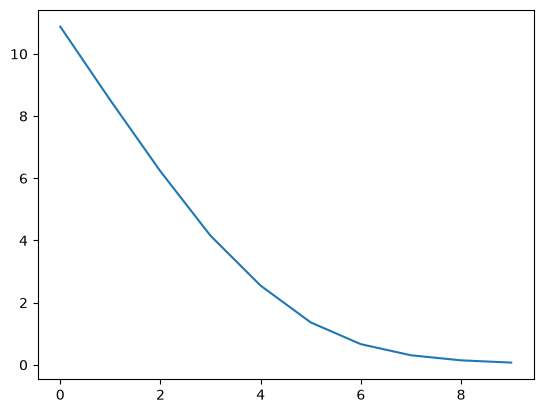

In [6]:
plot_training_error(losses)

In [8]:
opt_train_param_cnt = opt.count_trainable_params()
print(f'model params count: {gpt2_small.count_params()["trainable_params"]}')
print(f'optimizer params count: {opt_train_param_cnt}')
print(f'memory size: {opt_train_param_cnt * 4 / 1024}MiB')

model params count: 224080128
optimizer params count: 224080128
memory size: 875313.0MiB


Takeaways - AdamW optimizer doubles the total number of params count, thus also doubles FLOPs count during training.